# 🛒 SmartCart Customer Segmentation & Behavioral Analysis

## 📌 Project Overview
This project performs **Customer Segmentation** on the SmartCart e-commerce dataset using unsupervised Machine Learning techniques. By segmenting customers based on demographics, purchasing channels, living arrangements, and spending habits, we can derive actionable marketing strategies and personalized campaign models to optimize sales and revenue.

---

## 🛠️ Data Preprocessing & Feature Engineering
- **Missing Value Imputation:** Imputed missing values in `Income` using the median ($~24$ missing records).
- **Outlier Removal:** Filtered out severe data anomalies (customers aged $>90$ or earning $>\$600,000$).
- **Feature Creation:**
  - `Age`: Calculated based on birth year ($2026 - \text{Year\_Birth}$).
  - `customer_Tenure_days`: Derived total days active relative to the latest sign-up date.
  - `Total_spending`: Summed spending across all product categories (Wines, Fruits, Meat, Fish, Sweets, Gold).
  - `total_children`: Combined `Kidhome` and `Teenhome`.
  - Category Simplifications: Standardized `Education` into 3 tiers (*UnderGraduate*, *Graduate*, *PostGraduate*) and `Marital_Status` into `Living_With` (*Partner* vs. *Alone*).
- **Encoding & Scaling:** One-Hot Encoded categorical variables and standardized numerical features using `StandardScaler`.
- **Dimensionality Reduction:** Applied **3D Principal Component Analysis (PCA)** to retain the primary variance structure.

---

## 📊 Model Selection & Optimal Clusters
- **Clustering Algorithms Evaluated:** `K-Means` vs. `Agglomerative Clustering`.
- **Optimal $K$ Determination:** Evaluated using the **Elbow Method (via `kneed.KneeLocator`)** and **Silhouette Analysis**, confirming $K = 4$ as the optimal cluster count.
- **Selected Model:** **Agglomerative Clustering ($K=4$, Ward linkage)** yielded cleaner cluster boundaries in 3D space.

---

## 💡 Key Cluster Insights & E-Commerce Business Persona Summary

| Cluster | Business Persona | Avg. Income | Avg. Total Spend | Household Structure | Key Channel / Response Strategy |
| :---: | :--- | :---: | :---: | :--- | :--- |
| **0** | **Budget Families** | ~$39.7k | ~$222 | Partnered, ~1.24 Kids | High web visits, price-sensitive. Focus on family bundles & discounts. |
| **1** | **High-Value Couples** | ~$72.8k | **~$1,237** | Partnered, ~0.51 Kids | Multi-channel spenders (Store/Catalog/Web). Target with premium upselling & loyalty programs. |
| **2** | **Single Budget Shoppers** | ~$37.0k | ~$166 | Single, ~1.27 Kids | Low overall spending. Focus on essential product deals & cart-recovery incentives. |
| **3** | **High-Value Singles (VIPs)**| ~$70.7k | **~$1,190** | Single, ~0.46 Kids | **Highest Response Rate (32%)**. Target with exclusive campaign launches, direct mail & VIP perks. |

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [98]:
df = pd.read_csv("smartcart_customers.csv")

In [99]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [100]:
df.shape

(2240, 22)

In [101]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

### 1. Handle missing values 

In [102]:
df["Income"]=df["Income"].fillna(df["Income"].median())

#  Feature Engineering

In [103]:
# age 
df["Age"]= 2026-df["Year_Birth"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [104]:
# customer joing date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
refrence_data = df["Dt_Customer"].max()

df["customer_Tenure_days"] = (refrence_data -  df["Dt_Customer"]).dt.days  # days since the user joined 

In [105]:
# spending (wine + fruits + meat + fish + gold)
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [106]:
# childrens
df["total_children"] = df["Kidhome"] + df["Teenhome"]

In [107]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_Tenure_days', 'Total_spending',
       'total_children'],
      dtype='str')

In [108]:
# Education (categorical data)
df["Education"].value_counts() # we have(Graduation,phd,master,2n cycle,basic)

df["Education"]=df["Education"].replace({
    "Basic":"UnderGraduate","2n Cycle":"UnderGraduate",
    "Graduation":"Graduate",
    "Master": "PostGraduate",
    "PhD":"PostGraduate"
})
# we will divide it only into underGraduate, Graduate, postGraducate 


In [109]:
df["Education"].value_counts()
# divided into  3 category

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [110]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [111]:
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow": "Alone","Absurd":"Alone",
    "YOLO":"Alone"
})

In [112]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [113]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_spending,total_children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [114]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
col_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=col_to_drop)

In [115]:
df_cleaned.shape

(2240, 15)

In [116]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_spending,total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


###  Outliers

In [117]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'customer_Tenure_days', 'Total_spending', 'total_children',
       'Living_With'],
      dtype='str')

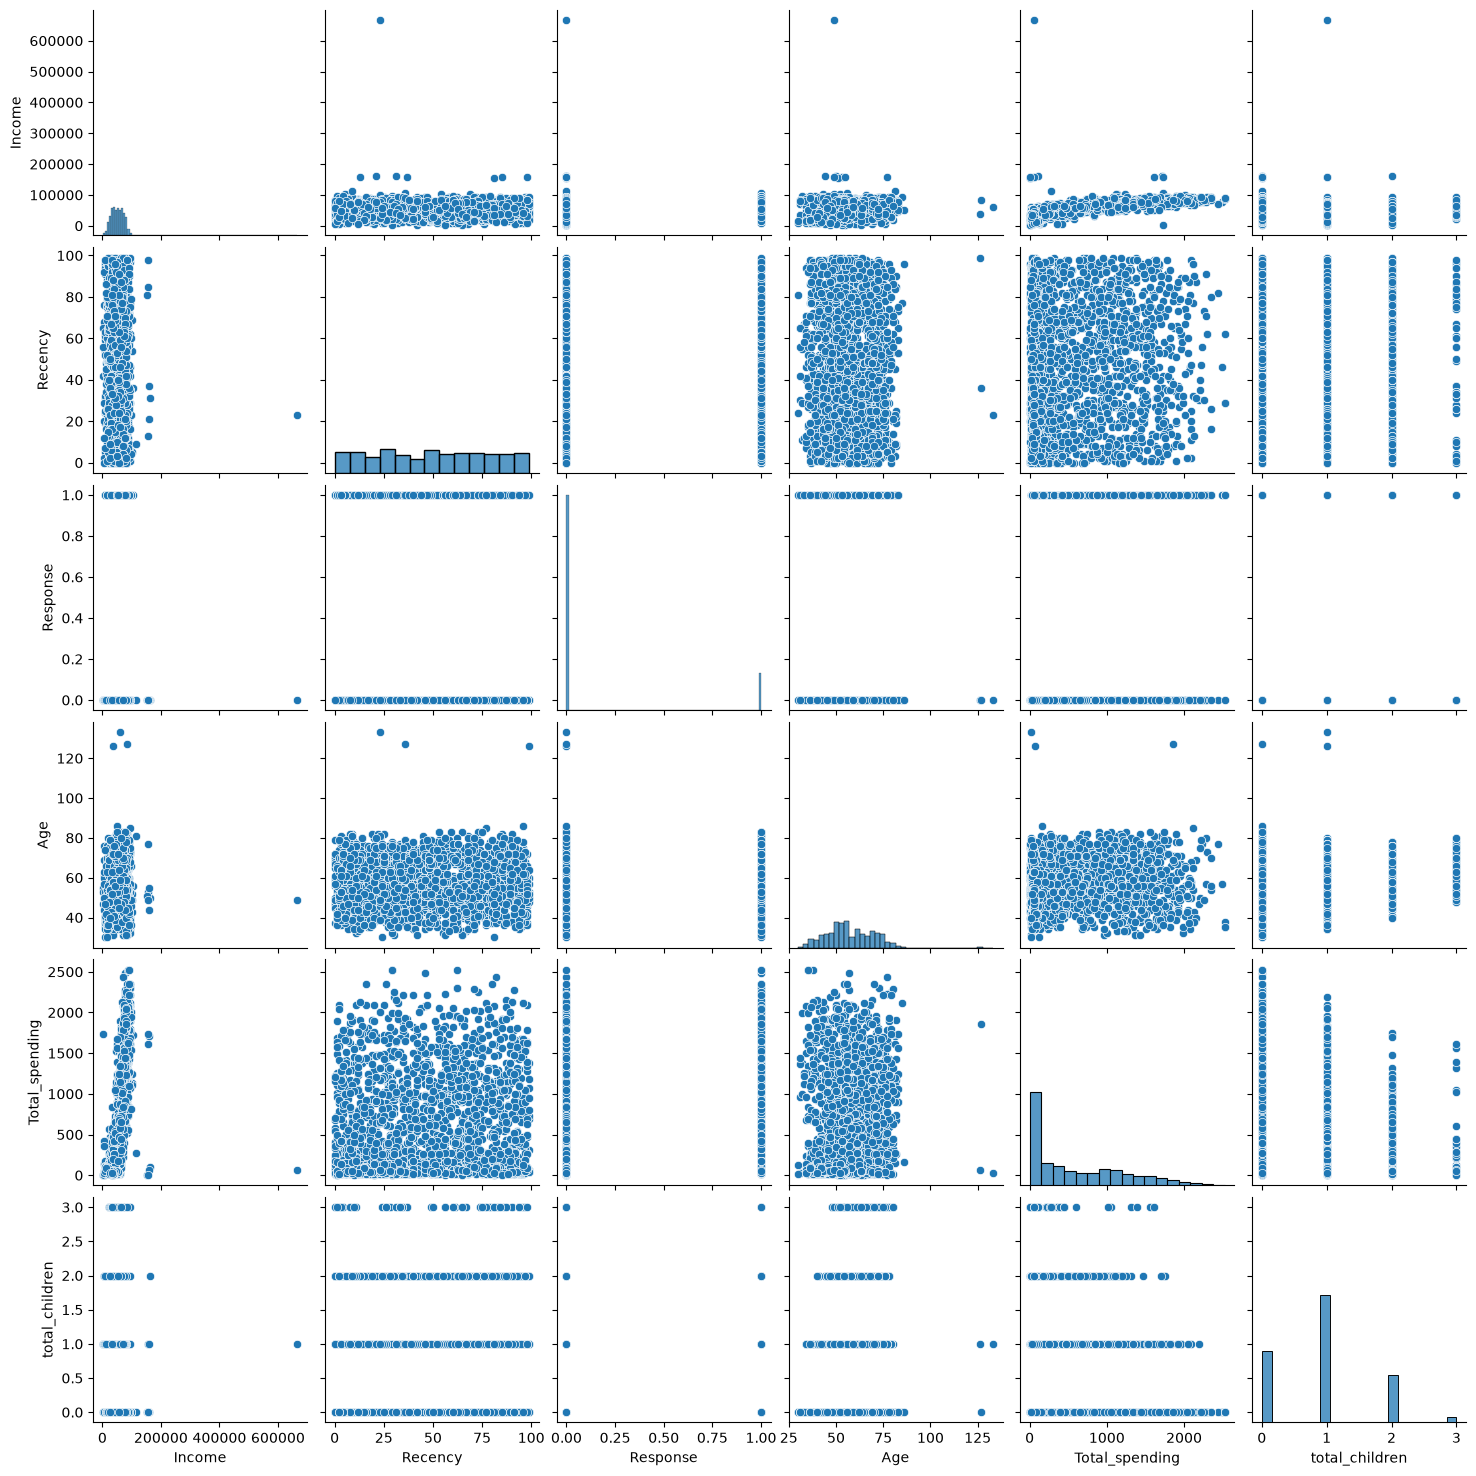

In [118]:
cols = ["Income","Recency","Response","Age","Total_spending","total_children"]

# relative plots of some features pair plots 
sns.pairplot(df_cleaned[cols])


In [119]:
# Remove the outlier 
print("data size with outleirs:",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)] # above 90 age got removed 
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size without outleirs:",len(df_cleaned))

data size with outleirs: 2240
data size without outleirs: 2236


### Heatmap

In [120]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

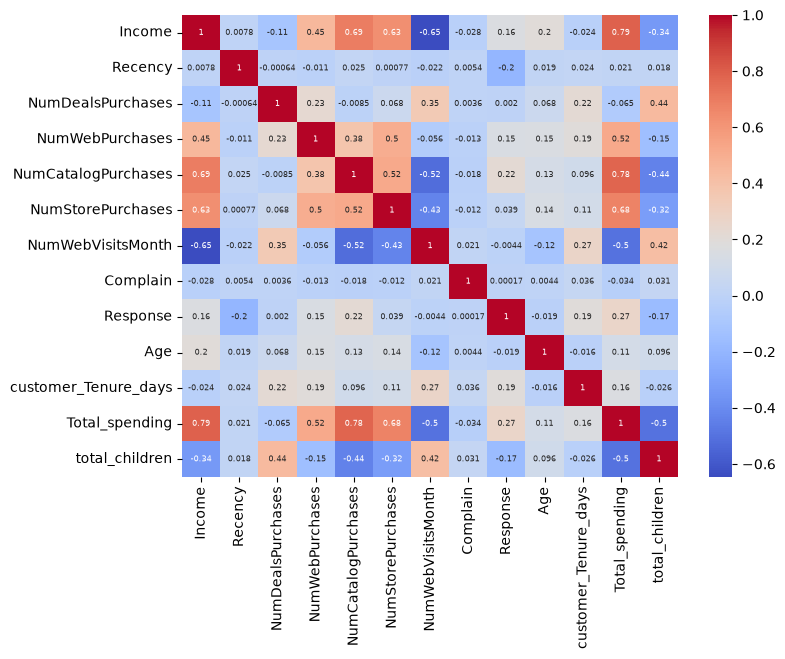

In [121]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size":6}
    
)

In [122]:
df_cleaned.shape

(2236, 15)

In [123]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_spending,total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


### Encoding

In [124]:
from sklearn.preprocessing import OneHotEncoder

In [125]:
ohe =  OneHotEncoder()

cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [126]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [127]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis = 1)

In [130]:
df_encoded.shape

(2236, 18)

In [131]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_spending,total_children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


### Scaling 

In [132]:
from sklearn.preprocessing import StandardScaler

In [133]:
x = df_encoded

In [134]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [135]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

### Visualize 

In [136]:
x_scaled.shape

(2236, 18)

In [137]:
# 2d
from sklearn.decomposition import PCA

In [138]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

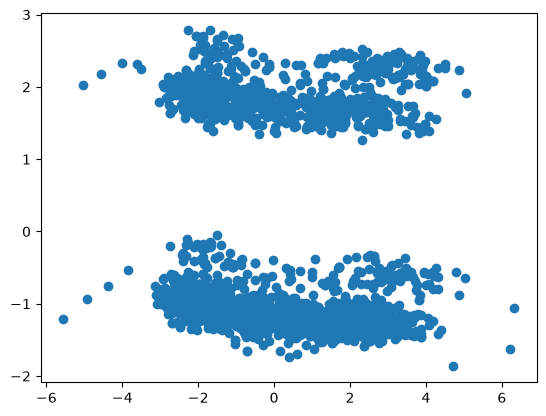

In [139]:
# plot 
plt.scatter(x_pca[:,0],x_pca[:,1])

In [140]:
pca.explained_variance_ratio_  # the info capature is less so increase the dim

array([0.23163158, 0.11385454])

In [141]:
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_scaled)

In [142]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

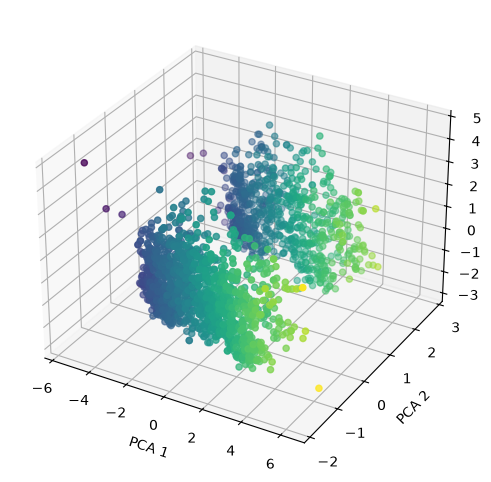

In [143]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=x_pca[:, 0])

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.show()

# Analyze K value 

### 1. Elobow Method 

In [144]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [147]:
knee =KneeLocator(range(1,11), wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [149]:
print("best_k :",optimal_k)

best_k : 4


Text(0, 0.5, 'WCSS')

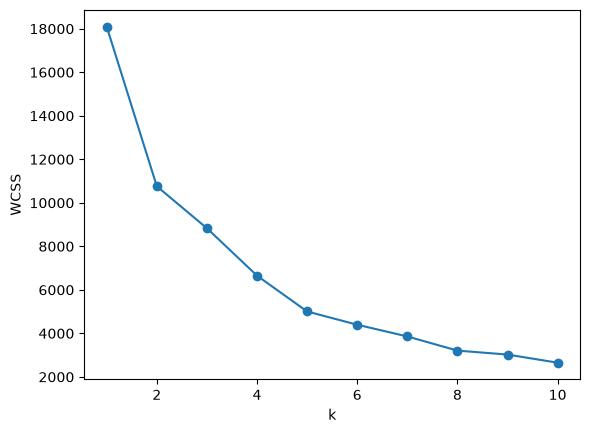

In [150]:
# plot for elbow 

plt.plot(range(1,11),wcss, marker="o")
plt.xlabel("k")
plt.ylabel("WCSS")

### 2. Silhouette Score 

Text(0, 0.5, 'Silhouette score')

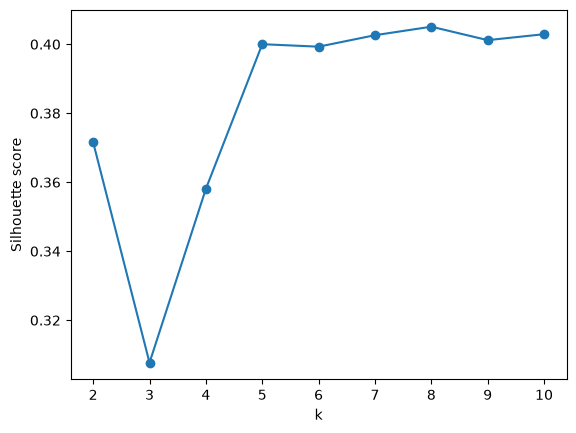

In [152]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)

# plot
plt.plot(range(2,11),scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SCORE')

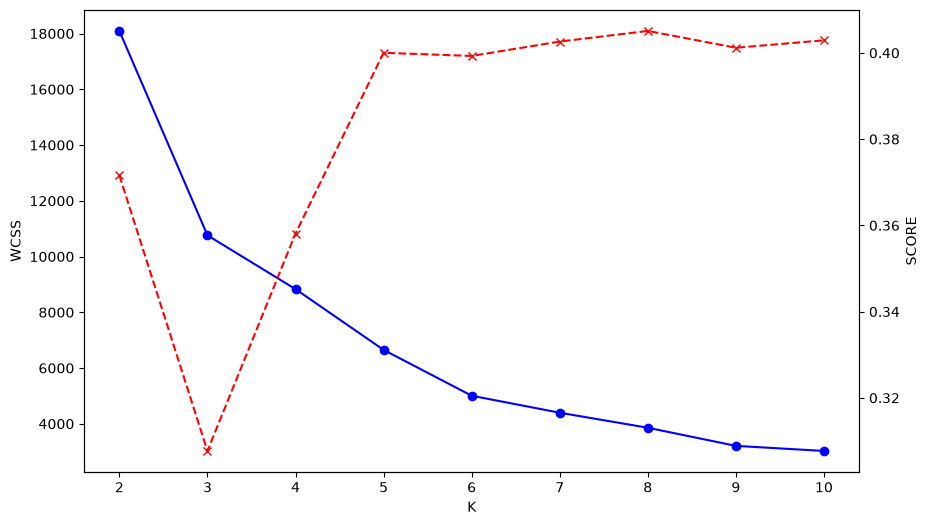

In [157]:
# combined plot 
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize = (10,6))
ax1.plot(k_range, wcss[:len(k_range)], marker = "o", color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 =  ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)],marker="x",color = "red",linestyle="--")
ax2.set_ylabel("SCORE")
# where both the elbow and score interset the nearest point to that is taken as the k value here 

# clustring 

In [158]:
# k_means 
kmeans = KMeans(n_clusters=4,random_state=42)
labels = kmeans.fit_predict(x_pca)

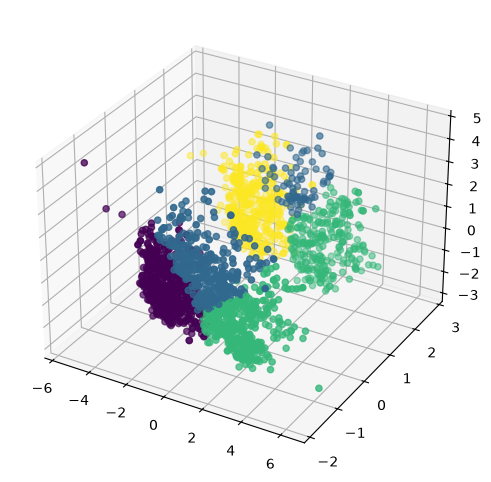

In [163]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2],c=labels)


In [164]:
# Agglomerative Clustring 
from sklearn.cluster import AgglomerativeClustering

In [165]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg= agg_clf.fit_predict(x_pca)

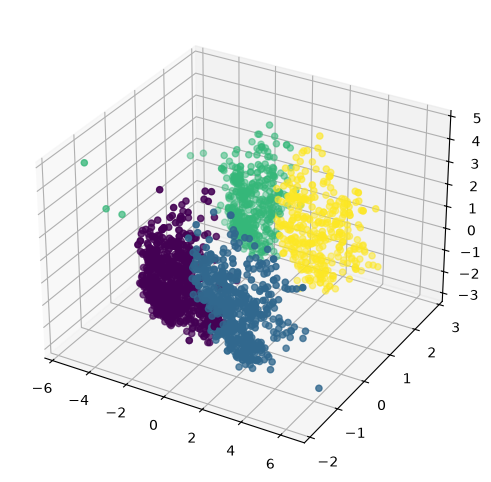

In [166]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2],c=labels_agg)


#### Better sepration of clustring for the AgglomerativeClustering model 

# Characterization of Clusters

In [179]:
x["cluster"] = labels_agg

In [180]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_Tenure_days,Total_spending,total_children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

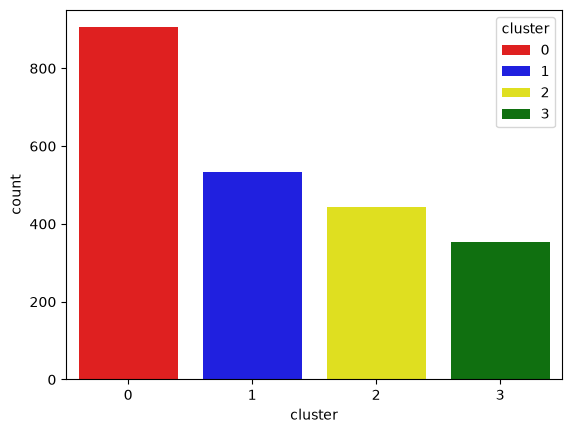

In [181]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=x["cluster"],palette = pal,hue=x["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

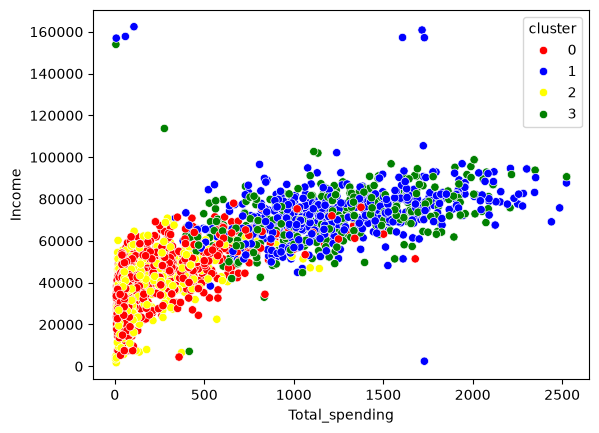

In [182]:
# income and spending patterns
sns.scatterplot(x=x["Total_spending"],y=x["Income"],hue = x["cluster"],palette=pal)

In [185]:
# cluster Summary
cluster_summary = x.groupby("cluster").mean()
print("cluster_summary :",cluster_summary)

cluster_summary :                Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  customer_Tenure_days  Total_spending  